In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import local_binary_pattern
from skimage.measure import regionprops, label
from skimage.morphology import closing, square

# Load the image
image_path = "C:\\Users\\PC\\Downloads\\IMG-20250210-WA0005.jpg"
image = cv2.imread(image_path)

In [2]:

# Step 1: Image Preprocessing
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    blur = cv2.GaussianBlur(gray, (5, 5), 0)  # Reduce noise
    equalized = cv2.equalizeHist(blur)  # Enhance contrast
    return equalized

# Step 2: Object Detection & Segmentation
def segment_objects(image):
    _, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)  # Otsu Thresholding
    kernel = np.ones((3, 3), np.uint8)
    morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)  # Morphological operations
    contours, _ = cv2.findContours(morph, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)  # Find contours
    return morph, contours

# Step 3: Feature Extraction (Size, Shape, Texture)
def extract_features(image, contours):
    features = []
    labeled_image = label(image)

    for contour in contours:
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        x, y, w, h = cv2.boundingRect(contour)
        aspect_ratio = float(w) / h

        # Extract texture features (LBP - Local Binary Pattern)
        lbp = local_binary_pattern(image[y:y+h, x:x+w], P=8, R=1, method="uniform")
        lbp_hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11), range=(0, 10))

        features.append({
            "area": area,
            "perimeter": perimeter,
            "aspect_ratio": aspect_ratio,
            "lbp_histogram": lbp_hist
        })
    
    return features


In [3]:
# Run Preprocessing
preprocessed = preprocess_image(image)

# Run Segmentation
segmented, contours = segment_objects(preprocessed)

# Extract Features
features = extract_features(preprocessed, contours)

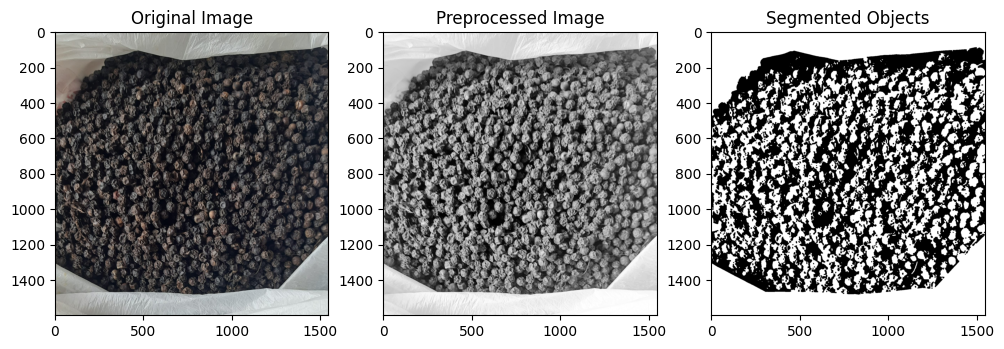

Extracted Features: [{'area': 5.5, 'perimeter': 12.242640614509583, 'aspect_ratio': 0.5, 'lbp_histogram': array([ 0,  3,  2, 10,  3,  0,  0,  0,  0,  0])}, {'area': 3.5, 'perimeter': 11.071067571640015, 'aspect_ratio': 0.8, 'lbp_histogram': array([0, 5, 0, 8, 3, 1, 0, 0, 0, 3])}, {'area': 18.5, 'perimeter': 26.242640614509583, 'aspect_ratio': 0.6, 'lbp_histogram': array([ 2,  2,  4, 24, 18,  5,  4,  0,  0,  1])}, {'area': 13.0, 'perimeter': 15.656854152679443, 'aspect_ratio': 1.2, 'lbp_histogram': array([ 1,  1,  2, 14, 10,  1,  0,  0,  0,  1])}, {'area': 1.5, 'perimeter': 5.414213538169861, 'aspect_ratio': 1.5, 'lbp_histogram': array([1, 1, 2, 2, 0, 0, 0, 0, 0, 0])}, {'area': 10.5, 'perimeter': 12.242640614509583, 'aspect_ratio': 0.8, 'lbp_histogram': array([ 0,  2,  2, 12,  4,  0,  0,  0,  0,  0])}, {'area': 0.0, 'perimeter': 2.0, 'aspect_ratio': 2.0, 'lbp_histogram': array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])}, {'area': 0.0, 'perimeter': 0.0, 'aspect_ratio': 1.0, 'lbp_histogram': array([

In [4]:
# Display Results
plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title("Original Image")
plt.subplot(1, 3, 2), plt.imshow(preprocessed, cmap="gray"), plt.title("Preprocessed Image")
plt.subplot(1, 3, 3), plt.imshow(segmented, cmap="gray"), plt.title("Segmented Objects")
plt.show()

# Print extracted features
print("Extracted Features:", features)